# 🔬 Robustness Testing

Objectif : vérifier que les résultats sont stables selon la taille du dataset, le fold de validation, et le temps.

In [1]:
# Cellule 1: Setup
import os, json, pickle, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) != 'experiments':
    if (Path(os.getcwd()) / 'experiments').exists():
        os.chdir(Path(os.getcwd()) / 'experiments')
sys.path.insert(0, str(Path(os.getcwd()).parent / 'utils'))
from fairness_metrics import compute_fairness_metrics, bootstrap_ci

R  = Path('../results')
R5 = R / 'phase5'
FIGS = R5 / 'figures'
R5.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
print(f'📁 {os.getcwd()}')
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from tqdm import tqdm
print('✅ Setup OK')


📁 /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments
✅ Setup OK


In [2]:
# Cellule 2: Charger données
with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(p):
    rows = []
    with open(p, encoding='utf-8') as f:
        for l in f:
            if l.strip(): rows.append(json.loads(l))
    return rows

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))
y_train  = le.transform(df_train['title'])
y_test   = le.transform(df_test['title'])
genders_train = df_train['gender'].values
genders_test  = df_test['gender'].values

try:
    with open('../results/phase2/best_embedding_model.json') as f:
        model_id = json.load(f)['model_id']
except FileNotFoundError:
    model_id = 'distilroberta-base'

safe  = model_id.replace('/', '_')
CACHE = Path('embedding_cache')
emb_train = np.load(list(CACHE.glob(f'{safe}_{len(df_train)}*.npy'))[0])
emb_test  = np.load(list(CACHE.glob(f'{safe}_{len(df_test)}*.npy'))[0])

try:
    with open('../results/phase2/best_rf_params.json') as f:
        rf_p = json.load(f)
except FileNotFoundError:
    rf_p = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2}

def make_rf():
    return RandomForestClassifier(
        n_estimators=rf_p.get('n_estimators',100),
        max_depth=rf_p.get('max_depth',20),
        min_samples_split=rf_p.get('min_samples_split',2),
        random_state=42, n_jobs=-1)

print(f'✅ Train={len(df_train)} | Test={len(df_test)}')


✅ Train=8000 | Test=1000


## 1️⃣ Cross-Validation 5-Fold des Métriques de Fairness

In [3]:
# Cellule 3: 5-Fold CV sur train+test (toutes données)
all_emb = np.vstack([emb_train, emb_test])
all_y   = np.concatenate([y_train, y_test])
all_g   = np.concatenate([genders_train, genders_test])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

print('🔄 5-Fold Cross-Validation...')
for fold, (tr_idx, val_idx) in enumerate(skf.split(all_emb, all_y)):
    rf = make_rf()
    rf.fit(all_emb[tr_idx], all_y[tr_idx])
    preds = rf.predict(all_emb[val_idx])
    fm = compute_fairness_metrics(all_y[val_idx], preds, all_g[val_idx], le.classes_)
    fm['fold'] = fold + 1
    cv_rows.append(fm)
    print(f'  Fold {fold+1}: acc={fm["accuracy"]:.4f}  ∆DP={fm["delta_dp"]:.4f}  ∆EO={fm["delta_eo"]:.4f}')

cv_df = pd.DataFrame(cv_rows)
print('\n📊 STATISTIQUES CV:')
for col in ['accuracy','delta_dp','delta_eo','delta_eqodds']:
    print(f'  {col}: mean={cv_df[col].mean():.4f}  std={cv_df[col].std():.4f}  '
          f'[{cv_df[col].min():.4f}, {cv_df[col].max():.4f}]')


🔄 5-Fold Cross-Validation...
  Fold 1: acc=0.8817  ∆DP=0.1853  ∆EO=0.2390
  Fold 2: acc=0.8967  ∆DP=0.1880  ∆EO=0.1742
  Fold 3: acc=0.8772  ∆DP=0.1705  ∆EO=0.1938
  Fold 4: acc=0.8800  ∆DP=0.1656  ∆EO=0.1787
  Fold 5: acc=0.8922  ∆DP=0.1760  ∆EO=0.1784

📊 STATISTIQUES CV:
  accuracy: mean=0.8856  std=0.0084  [0.8772, 0.8967]
  delta_dp: mean=0.1771  std=0.0095  [0.1656, 0.1880]
  delta_eo: mean=0.1928  std=0.0269  [0.1742, 0.2390]
  delta_eqodds: mean=0.1940  std=0.0266  [0.1742, 0.2390]


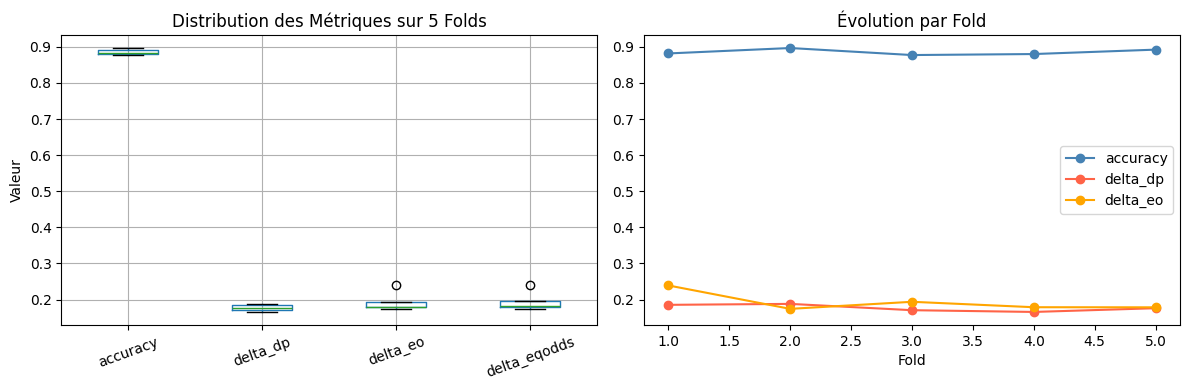

In [4]:
# Cellule 4: Visualisation CV
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics_plot = ['accuracy', 'delta_dp', 'delta_eo', 'delta_eqodds']

cv_df[metrics_plot].boxplot(ax=axes[0])
axes[0].set_title('Distribution des Métriques sur 5 Folds')
axes[0].set_ylabel('Valeur')
axes[0].tick_params(axis='x', rotation=20)

for col, color in zip(['accuracy','delta_dp','delta_eo'],['steelblue','tomato','orange']):
    axes[1].plot(cv_df['fold'], cv_df[col], marker='o', label=col, color=color)
axes[1].set_title('Évolution par Fold')
axes[1].set_xlabel('Fold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGS/'cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()


## 2️⃣ Sensibilité à la Taille du Jeu d'Entraînement

In [5]:
# Cellule 5: Entraîner sur N=500, 1000, 2000, 4000, 8000
SAMPLE_SIZES = [500, 1000, 2000, 4000, len(emb_train)]
size_rows = []

print('🔄 Test sur sous-échantillons...')
for n in SAMPLE_SIZES:
    # Stratified subsample
    idx = []
    for c in np.unique(y_train):
        c_idx = np.where(y_train == c)[0]
        k = max(1, int(n * len(c_idx) / len(y_train)))
        idx.extend(np.random.choice(c_idx, min(k, len(c_idx)), replace=False))
    idx = np.array(idx[:n])

    rf = make_rf()
    rf.fit(emb_train[idx], y_train[idx])
    preds = rf.predict(emb_test)
    fm = compute_fairness_metrics(y_test, preds, genders_test, le.classes_)
    fm['n_train'] = n
    size_rows.append(fm)
    print(f'  n={n:5d}: acc={fm["accuracy"]:.4f}  ∆DP={fm["delta_dp"]:.4f}  ∆EO={fm["delta_eo"]:.4f}')

size_df = pd.DataFrame(size_rows)


🔄 Test sur sous-échantillons...
  n=  500: acc=0.8320  ∆DP=0.1780  ∆EO=0.2083
  n= 1000: acc=0.8570  ∆DP=0.1839  ∆EO=0.2317
  n= 2000: acc=0.8720  ∆DP=0.1770  ∆EO=0.2382
  n= 4000: acc=0.8740  ∆DP=0.1720  ∆EO=0.2450
  n= 8000: acc=0.9020  ∆DP=0.1748  ∆EO=0.1788


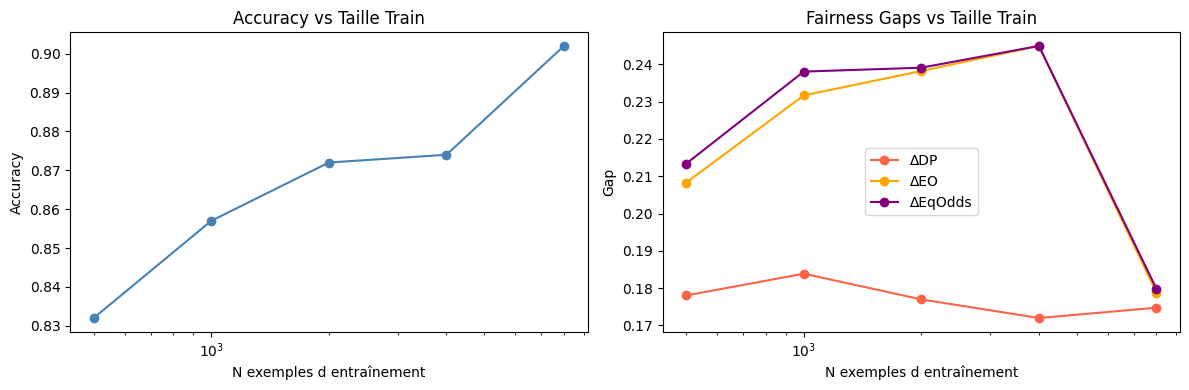

In [6]:
# Cellule 6: Visualisation sensibilité taille
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(size_df['n_train'], size_df['accuracy'], marker='o', color='steelblue')
axes[0].set_title('Accuracy vs Taille Train')
axes[0].set_xlabel('N exemples d entraînement')
axes[0].set_ylabel('Accuracy')
axes[0].set_xscale('log')

for col, color, label in [
    ('delta_dp','tomato','∆DP'),
    ('delta_eo','orange','∆EO'),
    ('delta_eqodds','purple','∆EqOdds')
]:
    axes[1].plot(size_df['n_train'], size_df[col], marker='o', color=color, label=label)
axes[1].set_title('Fairness Gaps vs Taille Train')
axes[1].set_xlabel('N exemples d entraînement')
axes[1].set_ylabel('Gap')
axes[1].set_xscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGS/'sample_size_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


## 3️⃣ Stabilité Temporelle

📅 ANALYSE TEMPORELLE
  2017 (n= 344): acc=0.8663  ∆EO=0.1468
  2018 (n= 656): acc=0.9162  ∆EO=0.1885


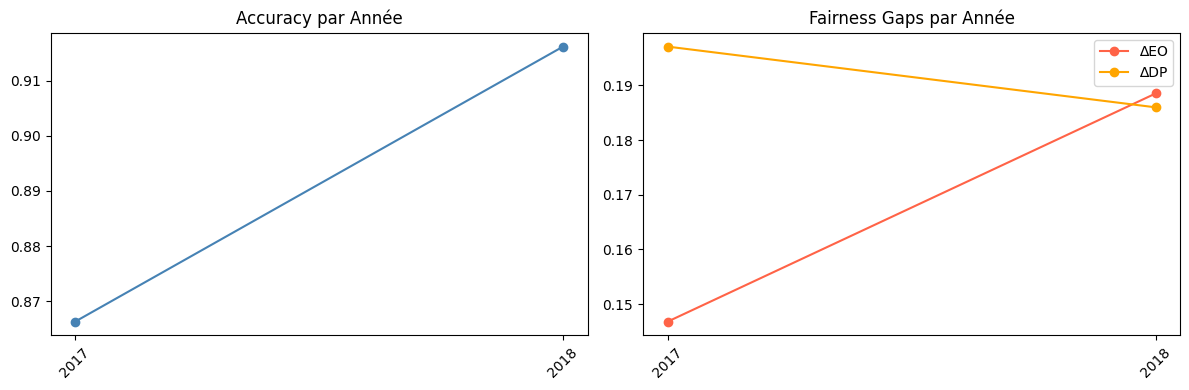

In [7]:
# Cellule 7: Analyse par période (colonne 'date' dans le dataset)
print('📅 ANALYSE TEMPORELLE')
print('='*40)

if 'date' in df_test.columns:
    df_test_copy = df_test.copy()
    df_test_copy['y_true'] = y_test
    df_test_copy['gender'] = genders_test

    # Charger le RF
    RF_PATH = Path('models/best_rf_embeddings.pkl')
    if RF_PATH.exists():
        with open(RF_PATH, 'rb') as f: rf_loaded = pickle.load(f)
    else:
        rf_loaded = make_rf()
        rf_loaded.fit(emb_train, y_train)

    preds_all = rf_loaded.predict(emb_test)
    df_test_copy['y_pred'] = preds_all

    # Extraire année
    df_test_copy['year'] = df_test_copy['date'].str[:4].astype(str)
    years = sorted(df_test_copy['year'].dropna().unique())

    temporal_rows = []
    for yr in years:
        mask = df_test_copy['year'] == yr
        if mask.sum() < 20: continue
        yt = df_test_copy.loc[mask, 'y_true'].values
        yp = df_test_copy.loc[mask, 'y_pred'].values
        gg = df_test_copy.loc[mask, 'gender'].values
        fm = compute_fairness_metrics(yt, yp, gg, le.classes_)
        fm['year'] = yr
        fm['n']    = mask.sum()
        temporal_rows.append(fm)
        print(f'  {yr} (n={mask.sum():4d}): acc={fm["accuracy"]:.4f}  ∆EO={fm["delta_eo"]:.4f}')

    if temporal_rows:
        temp_df = pd.DataFrame(temporal_rows)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(temp_df['year'], temp_df['accuracy'], marker='o', color='steelblue')
        axes[0].set_title('Accuracy par Année')
        axes[0].tick_params(axis='x', rotation=45)
        axes[1].plot(temp_df['year'], temp_df['delta_eo'], marker='o', color='tomato', label='∆EO')
        axes[1].plot(temp_df['year'], temp_df['delta_dp'], marker='o', color='orange', label='∆DP')
        axes[1].set_title('Fairness Gaps par Année')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].legend()
        plt.tight_layout()
        plt.savefig(FIGS/'temporal_stability.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('  ℹ️  Colonne "date" absente du test set')


## 4️⃣ Bootstrap CI sur les Configs Optimales

🔄 Bootstrap CI (1000 itérations) sur le RF baseline...
  accuracy            : 0.8986  95% CI=[0.8790, 0.9170]
  delta_dp            : 0.1745  95% CI=[0.1535, 0.1969]
  delta_eo            : 0.1801  95% CI=[0.1123, 0.2448]
  delta_eqodds        : 0.1822  95% CI=[0.1148, 0.2510]


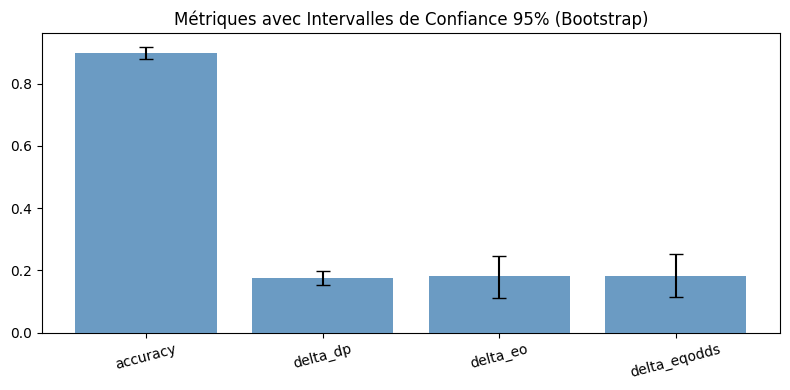

In [8]:
# Cellule 8: Bootstrap CI pour les 3 meilleures configs
print('🔄 Bootstrap CI (1000 itérations) sur le RF baseline...')

rf_final = make_rf()
rf_final.fit(emb_train, y_train)
preds_final = rf_final.predict(emb_test)

ci_rows = []
for metric in ['accuracy', 'delta_dp', 'delta_eo', 'delta_eqodds']:
    mean_v, lo, hi = bootstrap_ci(y_test, preds_final, genders_test,
                                   le.classes_, metric=metric, n_iter=1000)
    ci_rows.append({'metric': metric, 'mean': mean_v, 'ci_low': lo, 'ci_high': hi,
                    'ci_width': hi - lo})
    print(f'  {metric:20s}: {mean_v:.4f}  95% CI=[{lo:.4f}, {hi:.4f}]')

ci_final_df = pd.DataFrame(ci_rows)

# Barplot avec CI
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(ci_final_df))
ax.bar(x, ci_final_df['mean'], color='steelblue', alpha=0.8, zorder=3)
ax.errorbar(x, ci_final_df['mean'],
            yerr=[ci_final_df['mean']-ci_final_df['ci_low'],
                  ci_final_df['ci_high']-ci_final_df['mean']],
            fmt='none', color='black', capsize=5, zorder=4)
ax.set_xticks(x)
ax.set_xticklabels(ci_final_df['metric'], rotation=15)
ax.set_title('Métriques avec Intervalles de Confiance 95% (Bootstrap)')
plt.tight_layout()
plt.savefig(FIGS/'bootstrap_ci_final.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# Cellule 9: Sauvegarder
cv_df.to_csv(R5/'cv_results.csv', index=False)
size_df.to_csv(R5/'sample_size_sensitivity.csv', index=False)
ci_final_df.to_csv(R5/'bootstrap_ci_final.csv', index=False)
if 'temporal_rows' in dir() and temporal_rows:
    temp_df.to_csv(R5/'temporal_stability.csv', index=False)
print('💾 cv_results.csv | sample_size_sensitivity.csv | bootstrap_ci_final.csv')
print('🎉 Notebook 13 terminé!')


💾 cv_results.csv | sample_size_sensitivity.csv | bootstrap_ci_final.csv
🎉 Notebook 13 terminé!
